# Sun Baseline and Delay Determination

Split from `diagnostic_sun.ipynb`: shared setup cells followed by baseline and delay estimation workflows.

In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotter import (
    plot_baseline_vs_frequency,
    plot_drift_comparison,
    plot_fringe_rate_vs_frequency,
    plot_interval_baseline,
    plot_lag_delay_summary,
)


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/sun_calibration')
PLOT_BAND_GHZ = 9.915, 9.978

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {len(files)} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp                  = np.array([np.abs(f['corr']) for f in files]).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4f}  (max of unmasked channels across all captures)')


Loaded 2116 captures  |  9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Masked : [0, 256, 512, 768]  (['9.7900 GHz', '9.8525 GHz', '9.9150 GHz', '9.9775 GHz'])
Peak   : 2.1071  (max of unmasked channels across all captures)


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    return get_sun(Time(unix_t, format='unix')).ra.deg

# Sort files by mid-capture unix time
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j]  for j in order]
paths_s   = [paths[j]  for j in order]
N_cap     = len(files_s)

lst_arr     = np.array([_lst_deg(t)    for t in unix_sort])
sun_ra_arr  = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg      = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# ---------------------------------------------------------------------------
# Split into 2 chips at the largest inter-capture gap
# ---------------------------------------------------------------------------
_t_end_arr   = np.array([float(f['unix_time_end'])   for f in files_s])
_t_start_arr = np.array([float(f['unix_time_start']) for f in files_s])
_gaps        = _t_start_arr[1:] - _t_end_arr[:-1]
_split       = int(np.argmax(_gaps)) + 1          # first index of chip 1

_slices = [slice(0, _split), slice(_split, N_cap)]

# Per-chip views of every per-capture array
files_chips    = [[files_s[i]   for i in range(s.start, s.stop)] for s in _slices]
unix_chips     = [unix_sort[s]  for s in _slices]
ha_chips       = [ha_deg[s]     for s in _slices]
N_caps         = [s.stop - s.start for s in _slices]

print(f'Gap at index {_split-1}→{_split}: {_gaps[_split-1]:.1f} s  '
      f'({_gaps[_split-1]/60:.1f} min)')
print(f'Chip 0: {N_caps[0]} captures,  HA {ha_chips[0].min():.2f}° → {ha_chips[0].max():.2f}°')
print(f'Chip 1: {N_caps[1]} captures,  HA {ha_chips[1].min():.2f}° → {ha_chips[1].max():.2f}°')

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Sun RA   : {sun_ra_arr.min():.4f} -- {sun_ra_arr.max():.4f} deg  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f} deg)')
print(f'HA range : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')

Gap at index 522→523: 87.5 s  (1.5 min)
Chip 0: 523 captures,  HA -80.14° → -67.47°
Chip 1: 1593 captures,  HA -67.09° → -45.02°
Sun RA   : 358.7558 -- 358.8448 deg  (span 0.0890 deg)
HA range : -80.14° -> -45.02°  (35.12° span)
Peak channel : k=581,  f_sky=9.9318 GHz
Amp  (norm)  : mean=0.603,  std=0.114
Phase        : mean=7.3°,  std=171.0°


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_17648/3603536064.py:62: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


In [4]:
# ---------------------------------------------------------------------------
# DC offset correction per chip — avoids cross-chip mean contamination.
# Each chip's DC is estimated from within that chip only.
# corr_dc_chips[c] : (N_caps[c], N_CH)  DC-corrected complex visibility
# corr_dc           : (N_cap, N_CH)     full sequence (for non-gap-sensitive cells)
# ---------------------------------------------------------------------------

corr_dc_chips = []
for fchip in files_chips:
    mat = np.array([f['corr'].astype(complex) for f in fchip])   # (N_c, N_CH)
    mat[:, BAD_CHANNELS] = np.nan
    re_mean_c = np.nanmean(mat.real, axis=0)
    corr_dc_chips.append(mat - re_mean_c[np.newaxis, :])

corr_dc = np.vstack(corr_dc_chips)   # (N_cap, N_CH) — full sequence

/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_17648/2153674000.py:12: RuntimeWarning: Mean of empty slice
  re_mean_c = np.nanmean(mat.real, axis=0)


## Fringe frequency → baseline conversion

### Fringe phase model

For a two-element interferometer with east-west baseline $B_\mathrm{EW}$, the geometric path-length difference is

$$\Delta l = \mathbf{b}\cdot\hat{s} = -B_\mathrm{EW}\cos\delta\sin h$$

because the geographic east unit vector is always perpendicular to Earth's rotation axis (i.e. it has no component along the NCP direction), so **latitude does not appear**. The fringe phase is

$$\varphi(h) = -\frac{2\pi f_\mathrm{obs}}{c}\,B_\mathrm{EW}\cos\delta\sin h + \varphi_0$$

### Instantaneous fringe frequency

Differentiating with respect to $h$ and converting to **cycles per degree of HA**:

$$f_\mathrm{fringe}\,[\mathrm{cyc\,deg^{-1}}] = \frac{f_\mathrm{obs}}{c}\,B_\mathrm{EW}\cos\delta\,|\cos h|\cdot\frac{\pi}{180}$$

Note: it is $|\cos h|$, not $|\sin h|$. The fringe rate is **maximum at transit** ($h=0$, source moving fastest in E-W) and zero at $h=\pm90°$.

### Solving for $B_\mathrm{EW}$

$$\boxed{B_\mathrm{EW} = \frac{f_\mathrm{fringe}\cdot c}{f_\mathrm{obs}\,\cos\delta\,|\cos\bar{h}|\cdot(\pi/180)}}$$

where $\bar{h}$ is the mean hour angle during the observation.

### Parameters (NCH X-band interferometer)

| Symbol | Value | Note |
|--------|-------|------|
| $f_\mathrm{obs}$ | $F\_SKY\_GHZ[K\_CH]$ GHz | sky frequency of the channel |
| $c$ | $3\times10^8$ m s$^{-1}$ | |
| $\delta_\odot$ | $\approx -1°$ to $+23°$ | Sun's declination (seasonal) |
| $\bar{h}$ | from `ha_deg.mean()` | mean HA of the capture window |

### Numerical shorthand

With the Sun near the equinox ($\cos\delta\approx1$):

$$B_\mathrm{EW} \approx \frac{1.034}{|\cos\bar{h}|}\;\mathrm{m}\quad\text{per cyc deg}^{-1}\text{ of fringe frequency at }f_\mathrm{obs}=9.9365\text{ GHz}$$

**Example:** $f_\mathrm{fringe}=0.600$ cyc deg$^{-1}$ at $\bar{h}\approx26°$ gives $B_\mathrm{EW}\approx1.15$ m, which is far below the nominal 15 m — meaning 0.600 cyc deg$^{-1}$ is likely a sidelobe. The fundamental fringe near transit from a 15 m baseline would appear at $f\approx f_\mathrm{obs}\cdot15\cdot1\cdot|\cos\bar{h}|\cdot\pi/180\,/c\approx3.8$ cyc deg$^{-1}$.

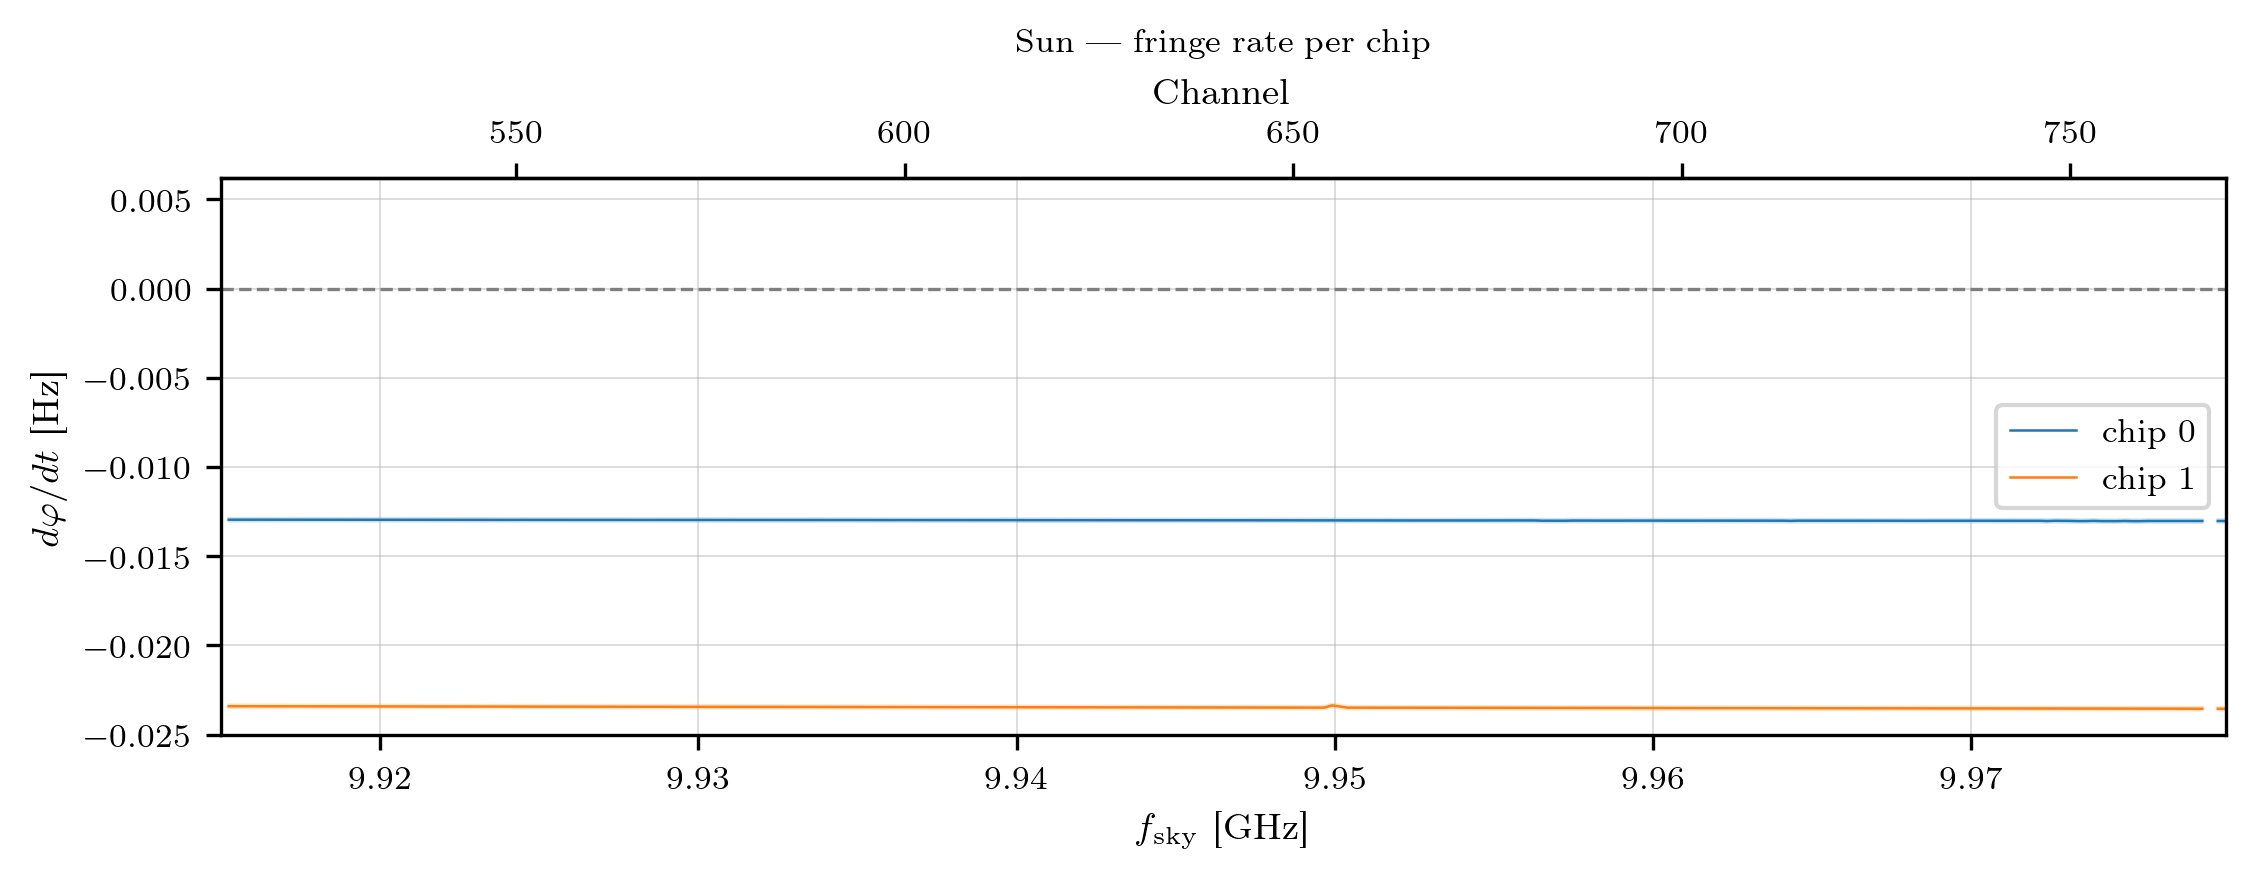

In [5]:
# ---------------------------------------------------------------------------
# Fringe rate: d φ / dt  — polyfit estimator per channel, per chip
# Phase is unwrapped within each chip to avoid the gap discontinuity.
# x: f_sky [GHz],  y: dφ/dt [Hz]
# ---------------------------------------------------------------------------

_omega_sid_deg_s = (2 * np.pi / 86164.1) * (180 / np.pi)  # deg/s

_dphi_dt_chips     = []
_dphi_dt_err_chips = []

for c, (ha_c, dc_c) in enumerate(zip(ha_chips, corr_dc_chips)):
    _t_ha_c = ha_c / _omega_sid_deg_s
    _phase_t_uw = np.unwrap(np.angle(dc_c), axis=0).astype(float)
    _phase_t_uw[:, BAD_CHANNELS] = np.nan
    _t_c = _t_ha_c - _t_ha_c.mean()

    _dphi_dt     = np.full(N_CH, np.nan)
    _dphi_dt_err = np.full(N_CH, np.nan)
    for k in range(N_CH):
        valid = np.isfinite(_phase_t_uw[:, k])
        if valid.sum() < 4:
            continue
        coeffs, (res, *_) = np.polynomial.polynomial.polyfit(
            _t_c[valid], _phase_t_uw[valid, k], 1, full=True
        )
        _dphi_dt[k] = coeffs[1] / (2 * np.pi)
        _n = valid.sum()
        _resid_std = np.sqrt(res[0] / (_n - 2)) if len(res) else np.nan
        _t_rms = np.sqrt(np.sum(_t_c[valid]**2))
        _dphi_dt_err[k] = _resid_std / (2 * np.pi * _t_rms)

    _dphi_dt_chips.append(_dphi_dt)
    _dphi_dt_err_chips.append(_dphi_dt_err)

fig, ax = plot_fringe_rate_vs_frequency(
    f_sky_ghz=F_SKY_GHZ,
    dphi_dt_chips=_dphi_dt_chips,
    dphi_dt_err_chips=_dphi_dt_err_chips,
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
)
plt.show()


Chip 0:  HA -80.14° → -67.47°  |  δ=-0.53°  |  B_EW = 18.890 ± 0.020 m
Chip 1:  HA -67.09° → -45.02°  |  δ=-0.51°  |  B_EW = 17.327 ± 0.004 m


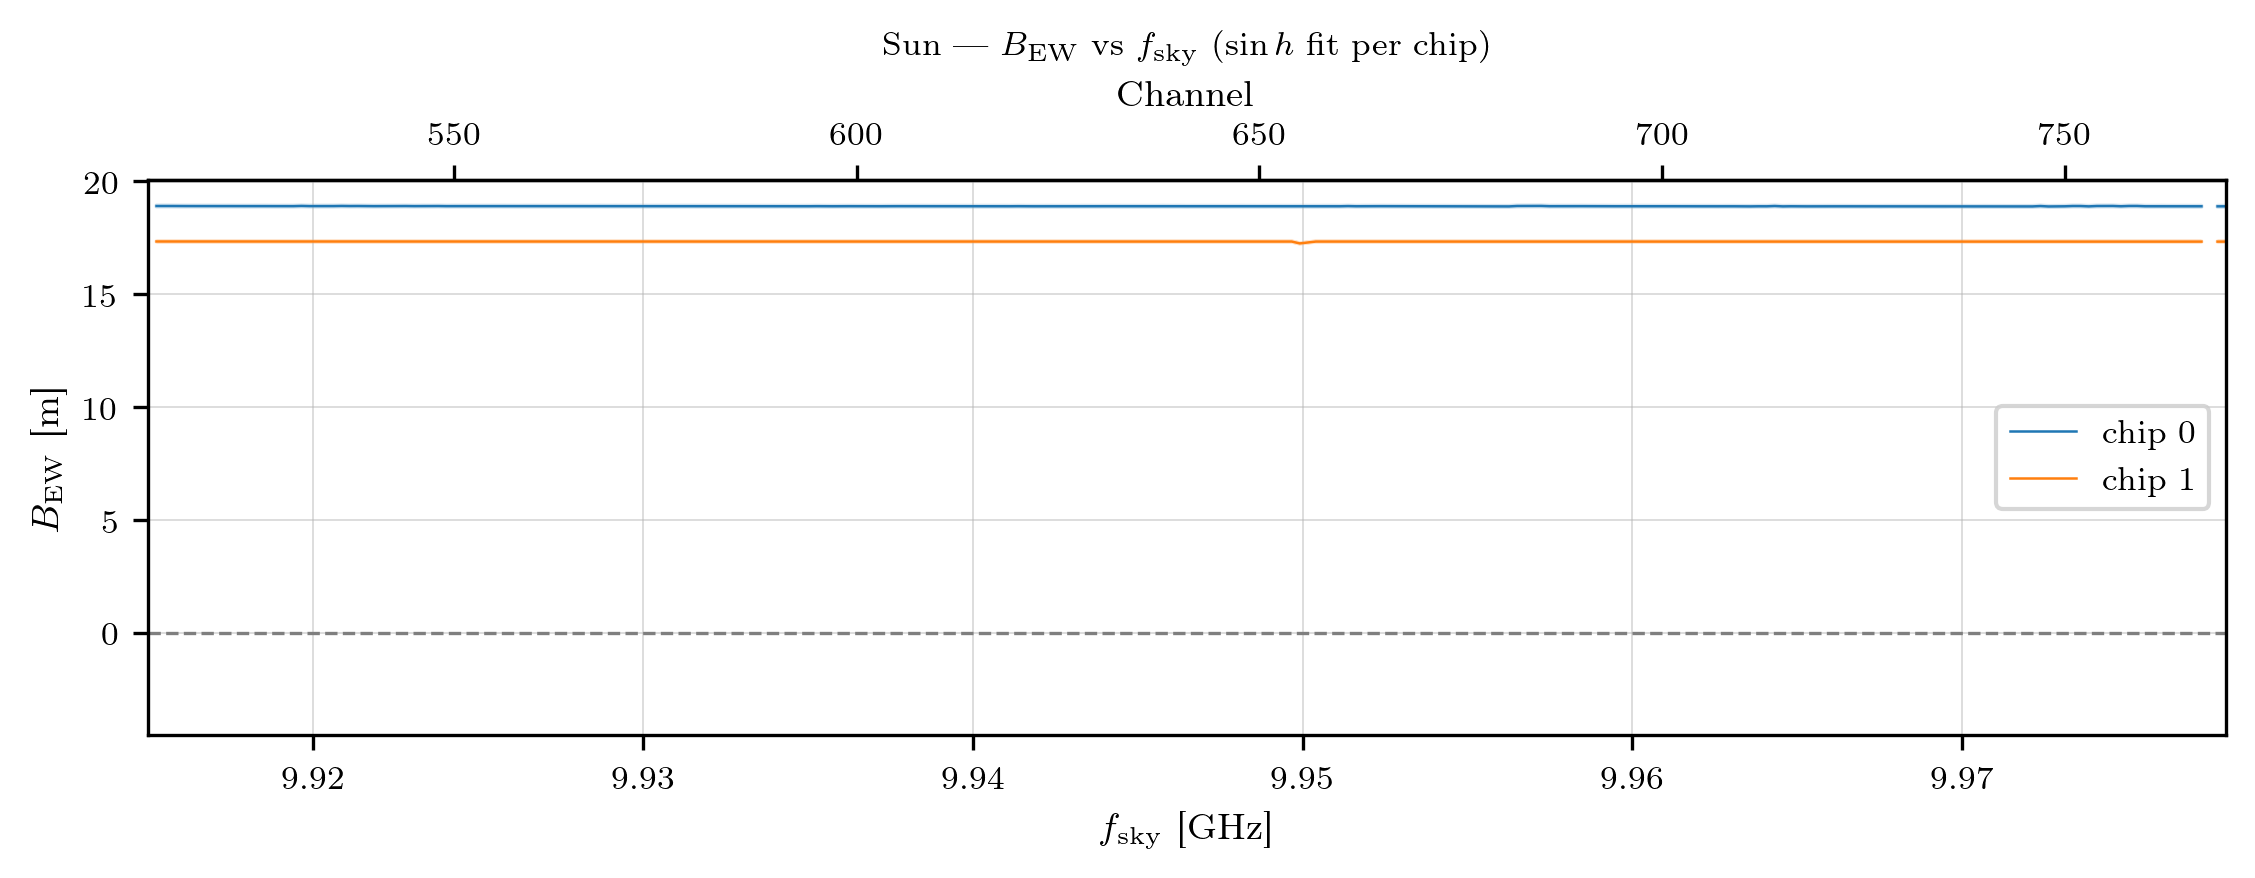

In [6]:
# ---------------------------------------------------------------------------
# Baseline B_EW vs f_sky — fit φ vs sin(h) per channel, per chip
#
# Model: φ(h) = A·sin(h) + φ_0
#   A = -(2π f_obs / c) · B_EW · cos(δ)
#   → B_EW(ν) = -A · c / (2π f_obs · cos(δ))
# ---------------------------------------------------------------------------

_C = 299792458.0

_B_EW_chips     = []
_B_EW_err_chips = []

for c, (ha_c, dc_c, unix_c) in enumerate(zip(ha_chips, corr_dc_chips, unix_chips)):
    _dec_deg = np.mean([get_sun(Time(t, format='unix')).dec.deg for t in unix_c])
    _cos_dec = np.cos(np.radians(_dec_deg))
    _sin_h   = np.sin(np.radians(ha_c))
    _sin_h_c = _sin_h - _sin_h.mean()

    _phase_uw = np.unwrap(np.angle(dc_c), axis=0).astype(float)
    _phase_uw[:, BAD_CHANNELS] = np.nan

    _B_EW     = np.full(N_CH, np.nan)
    _B_EW_err = np.full(N_CH, np.nan)
    for k in range(N_CH):
        valid = np.isfinite(_phase_uw[:, k])
        if valid.sum() < 4:
            continue
        coeffs, (res, *_) = np.polynomial.polynomial.polyfit(
            _sin_h_c[valid], _phase_uw[valid, k], 1, full=True
        )
        A = coeffs[1]
        _B_EW[k] = -A * _C / (2 * np.pi * F_SKY_GHZ[k] * 1e9 * _cos_dec)
        _n = valid.sum()
        _resid_std = np.sqrt(res[0] / (_n - 2)) if len(res) else np.nan
        _sin_h_rms = np.sqrt(np.sum(_sin_h_c[valid]**2))
        _B_EW_err[k] = _C * _resid_std / (2 * np.pi * F_SKY_GHZ[k] * 1e9 * _cos_dec * _sin_h_rms)

    _B_EW_chips.append(_B_EW)
    _B_EW_err_chips.append(_B_EW_err)

    _mean = np.nanmean(_B_EW[_ch_lo:_ch_hi])
    _merr = np.nanmean(_B_EW_err[_ch_lo:_ch_hi])
    print(f'Chip {c}:  HA {ha_c.min():.2f}° → {ha_c.max():.2f}°  |  '
          f'δ={_dec_deg:.2f}°  |  B_EW = {_mean:.3f} ± {_merr:.3f} m')

fig, ax = plot_baseline_vs_frequency(
    f_sky_ghz=F_SKY_GHZ,
    baseline_chips=_B_EW_chips,
    baseline_err_chips=_B_EW_err_chips,
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
)
plt.show()


Chip 0:  B_EW = 16.9241 ± 0.3377 m  |  τ_inst = 53.8666 ns  |  Lag SNR mean=22.3  min=17.2
Chip 1:  B_EW = 16.3621 ± 0.0405 m  |  τ_inst = 52.4221 ns  |  Lag SNR mean=22.2  min=19.0


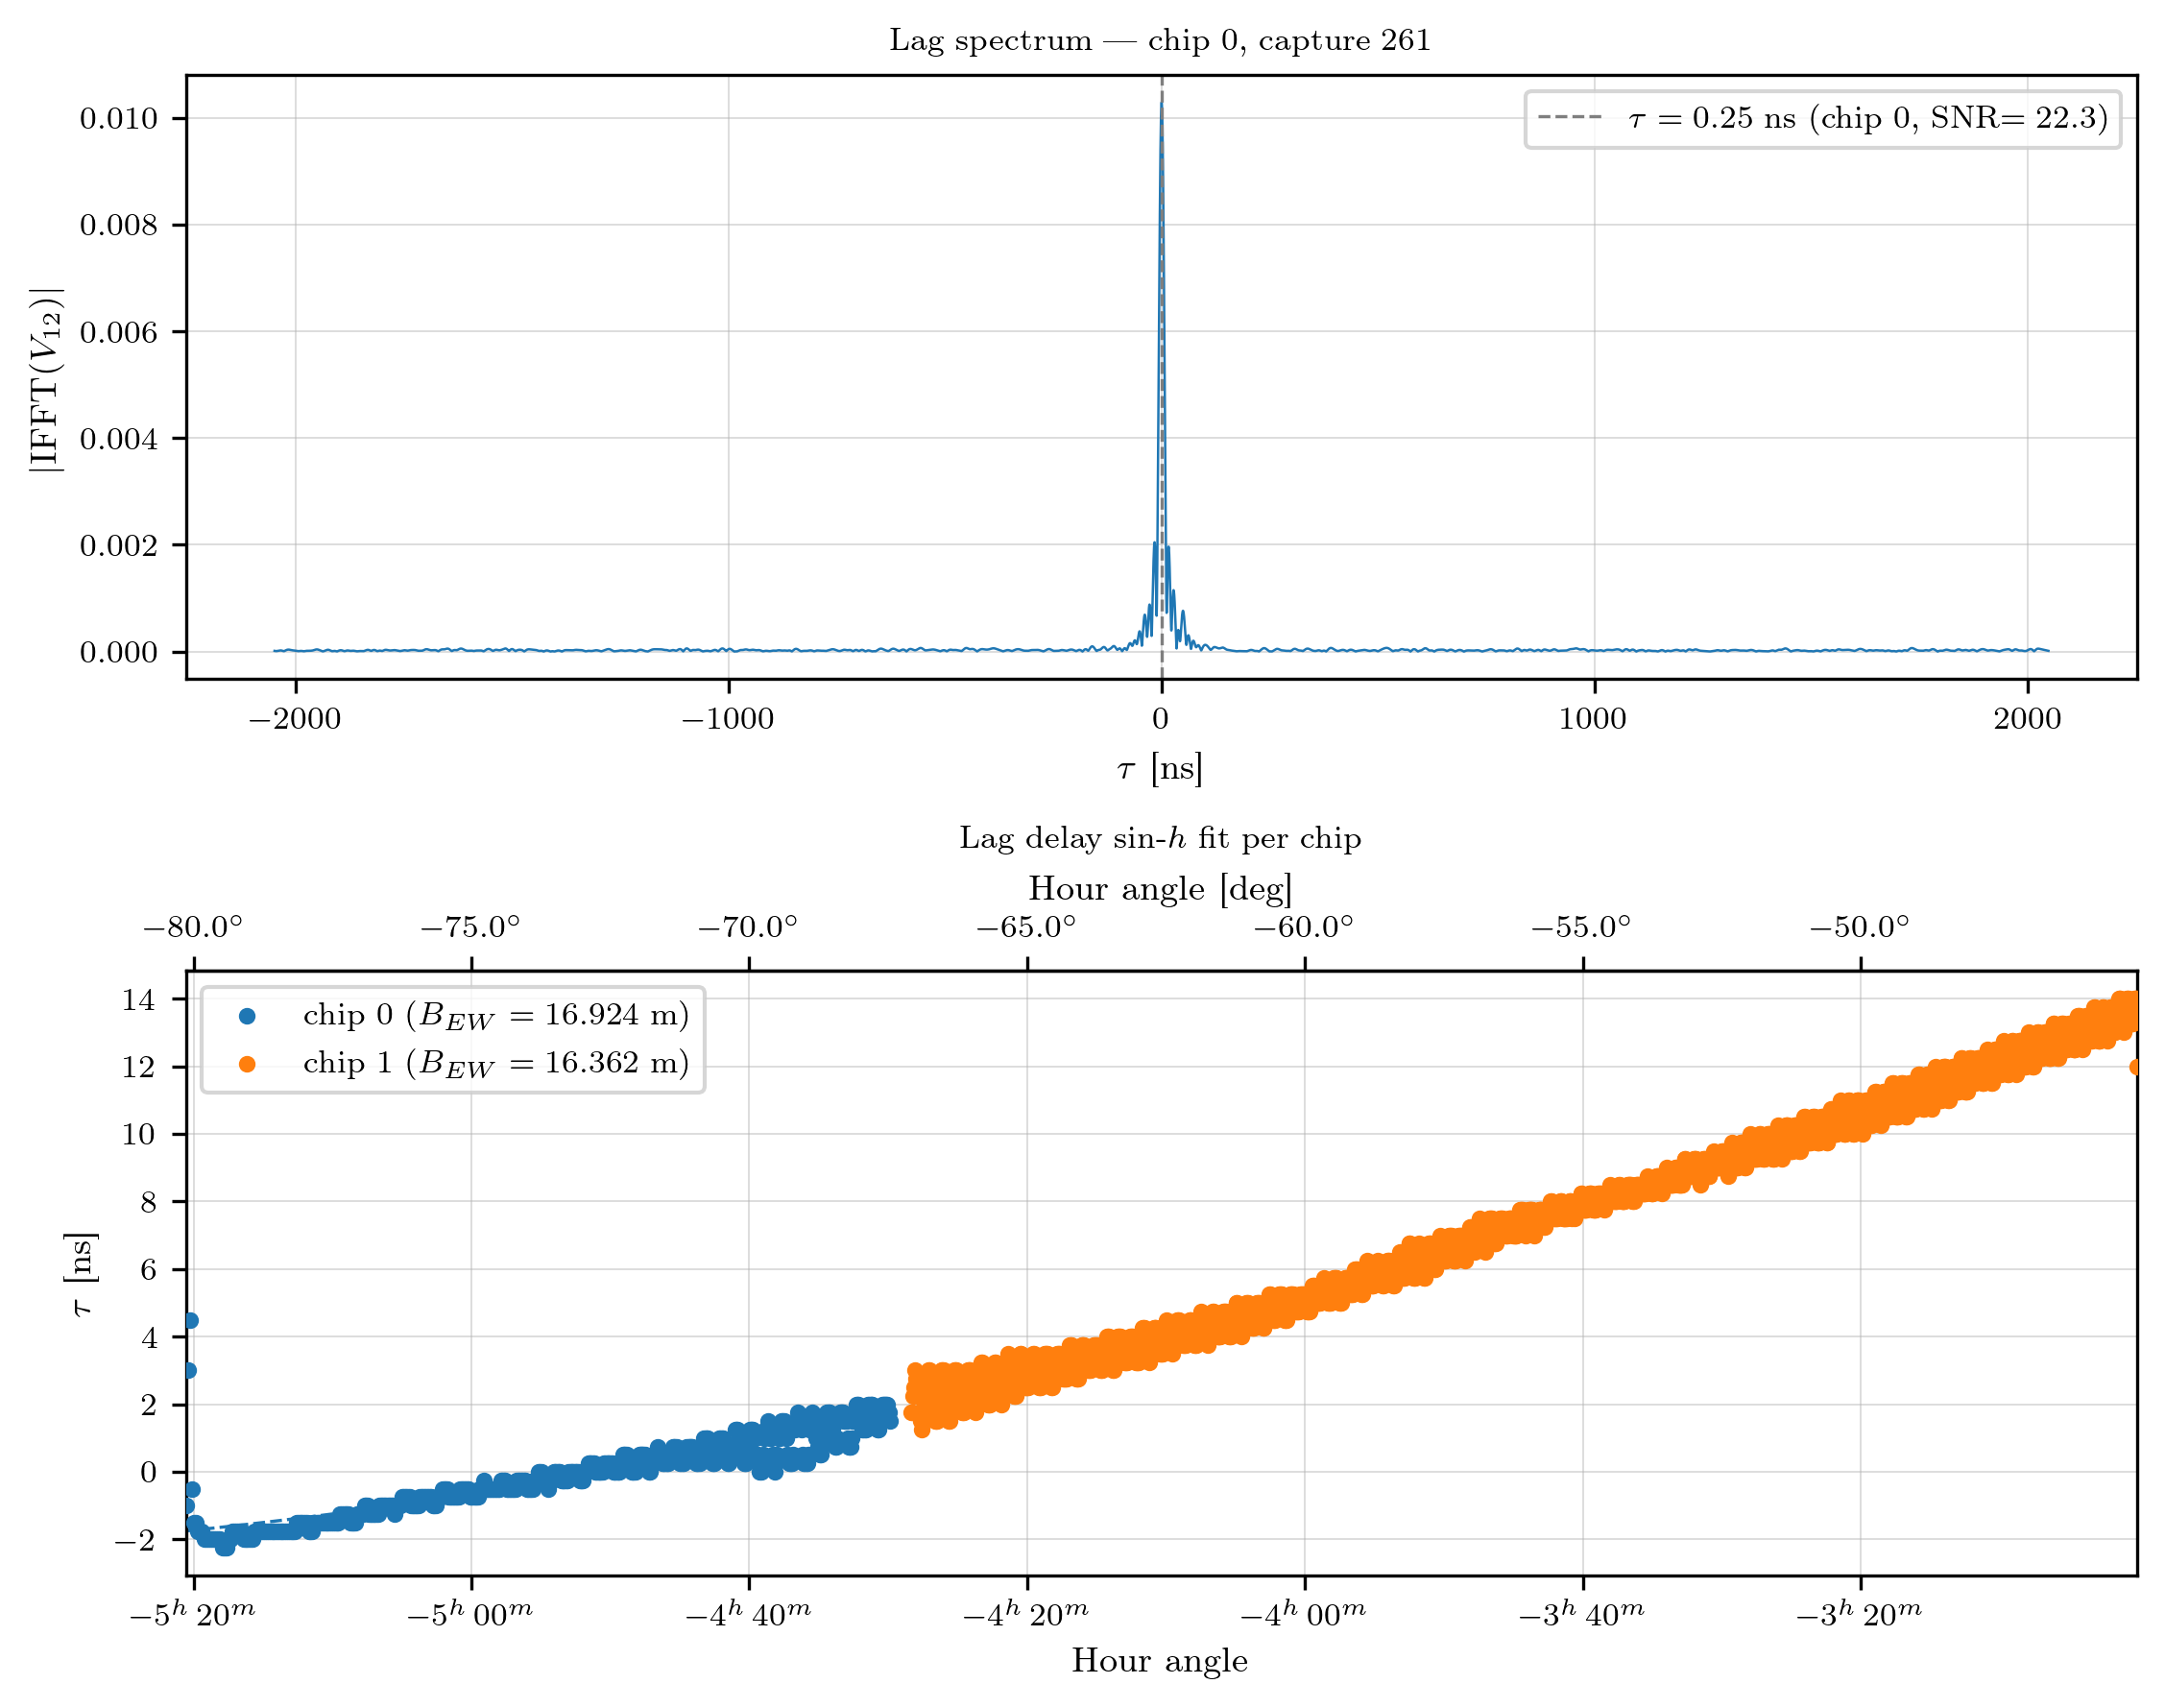

In [7]:
# ---------------------------------------------------------------------------
# Lag-spectrum delay — IFFT of cross-spectrum per capture, per chip
#
# lag(τ) = IFFT(V(ν));  peak of |lag| gives geometric delay directly.
# Fit  τ(h) = A·sin(h) + τ_inst  per chip to extract B_EW.
# ---------------------------------------------------------------------------

PAD_FAC = 16
N_pad   = N_CH * PAD_FAC
_tau_axis_ns = np.fft.fftshift(np.fft.fftfreq(N_pad, d=DF_HZ)) * 1e9
_C_lag = 299792458.0

_tau_lag_chips      = []
_lag_snr_chips      = []
_B_EW_lag_chips     = []
_B_EW_lag_err_chips = []
_coeffs_lag_chips   = []
_sin_h_lag_chips    = []

for c, (ha_c, dc_c, unix_c) in enumerate(zip(ha_chips, corr_dc_chips, unix_chips)):
    nc = N_caps[c]
    _tau_lag = np.full(nc, np.nan)
    _lag_snr = np.full(nc, np.nan)

    for n in range(nc):
        vis = dc_c[n, :].copy()
        for _k in BAD_CHANNELS:
            _lo = _k - 1 if _k > 0 else _k + 1
            _hi = _k + 1 if _k < N_CH - 1 else _k - 1
            vis[_k] = (vis[_lo] + vis[_hi]) / 2
        lag = np.fft.fftshift(np.fft.ifft(vis, n=N_pad))
        amp = np.abs(lag)
        i_pk = np.argmax(amp)
        _tau_lag[n] = _tau_axis_ns[i_pk]
        mask = np.ones(N_pad, dtype=bool)
        mask[max(0, i_pk - 5) : min(N_pad, i_pk + 6)] = False
        _lag_snr[n] = amp[i_pk] / amp[mask].std()

    _dec_lag     = np.mean([get_sun(Time(t, format='unix')).dec.deg for t in unix_c])
    _cos_dec_lag = np.cos(np.radians(_dec_lag))
    _sin_h_lag   = np.sin(np.radians(ha_c))
    _valid_lag   = np.isfinite(_tau_lag)

    _coeffs_lag, (_res_lag, *_) = np.polynomial.polynomial.polyfit(
        _sin_h_lag[_valid_lag], _tau_lag[_valid_lag], 1, full=True
    )
    _B_EW_lag = _coeffs_lag[1] * 1e-9 * _C_lag / _cos_dec_lag

    _nl            = _valid_lag.sum()
    _resid_std_lag = np.sqrt(_res_lag[0] / (_nl - 2)) if len(_res_lag) else np.nan
    _sin_h_rms_lag = np.sqrt(np.sum((_sin_h_lag[_valid_lag] - _sin_h_lag[_valid_lag].mean())**2))
    _B_EW_lag_err  = _resid_std_lag * 1e-9 * _C_lag / (_cos_dec_lag * _sin_h_rms_lag)

    _tau_lag_chips.append(_tau_lag)
    _lag_snr_chips.append(_lag_snr)
    _B_EW_lag_chips.append(_B_EW_lag)
    _B_EW_lag_err_chips.append(_B_EW_lag_err)
    _coeffs_lag_chips.append(_coeffs_lag)
    _sin_h_lag_chips.append(_sin_h_lag)

    print(f'Chip {c}:  B_EW = {_B_EW_lag:.4f} ± {_B_EW_lag_err:.4f} m'
          f'  |  τ_inst = {_coeffs_lag[0]:.4f} ns'
          f'  |  Lag SNR mean={np.nanmean(_lag_snr):.1f}  min={np.nanmin(_lag_snr):.1f}')

# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------

# Example lag spectrum — chip 0 median capture
_i_ex0  = N_caps[0] // 2
_vis_ex = corr_dc_chips[0][_i_ex0, :].copy()
for _k in BAD_CHANNELS:
    _lo = _k - 1 if _k > 0 else _k + 1
    _hi = _k + 1 if _k < N_CH - 1 else _k - 1
    _vis_ex[_k] = (_vis_ex[_lo] + _vis_ex[_hi]) / 2
_lag_ex = np.fft.fftshift(np.fft.ifft(_vis_ex, n=N_pad))

fig, axes = plot_lag_delay_summary(
    tau_axis_ns=_tau_axis_ns,
    lag_amp=np.abs(_lag_ex),
    tau_peak_ns=_tau_lag_chips[0][_i_ex0],
    lag_snr=_lag_snr_chips[0][_i_ex0],
    capture_index=_i_ex0,
    ha_chips=ha_chips,
    tau_lag_chips=_tau_lag_chips,
    baseline_lag_chips=_B_EW_lag_chips,
    sin_h_lag_chips=_sin_h_lag_chips,
    coeffs_lag_chips=_coeffs_lag_chips,
    ha_limits_deg=(ha_deg.min(), ha_deg.max()),
)
plt.show()


HA [-80.0° to -75.0°]  chip 0  n=168  B_EW = 24.721 ± 0.611 m
HA [-75.0° to -70.0°]  chip 0  n=222  B_EW = 16.039 ± 0.558 m
HA [-70.0° to -65.0°]  chip 0  n=129  B_EW = 21.679 ± 2.449 m
HA [-70.0° to -65.0°]  chip 1  n=126  B_EW = 17.080 ± 3.034 m
HA [-65.0° to -60.0°]  chip 1  n=318  B_EW = 16.478 ± 0.458 m
HA [-60.0° to -55.0°]  chip 1  n=332  B_EW = 18.770 ± 0.329 m
HA [-55.0° to -50.0°]  chip 1  n=405  B_EW = 15.548 ± 0.242 m
HA [-50.0° to -45.0°]  chip 1  n=412  B_EW = 16.033 ± 0.301 m


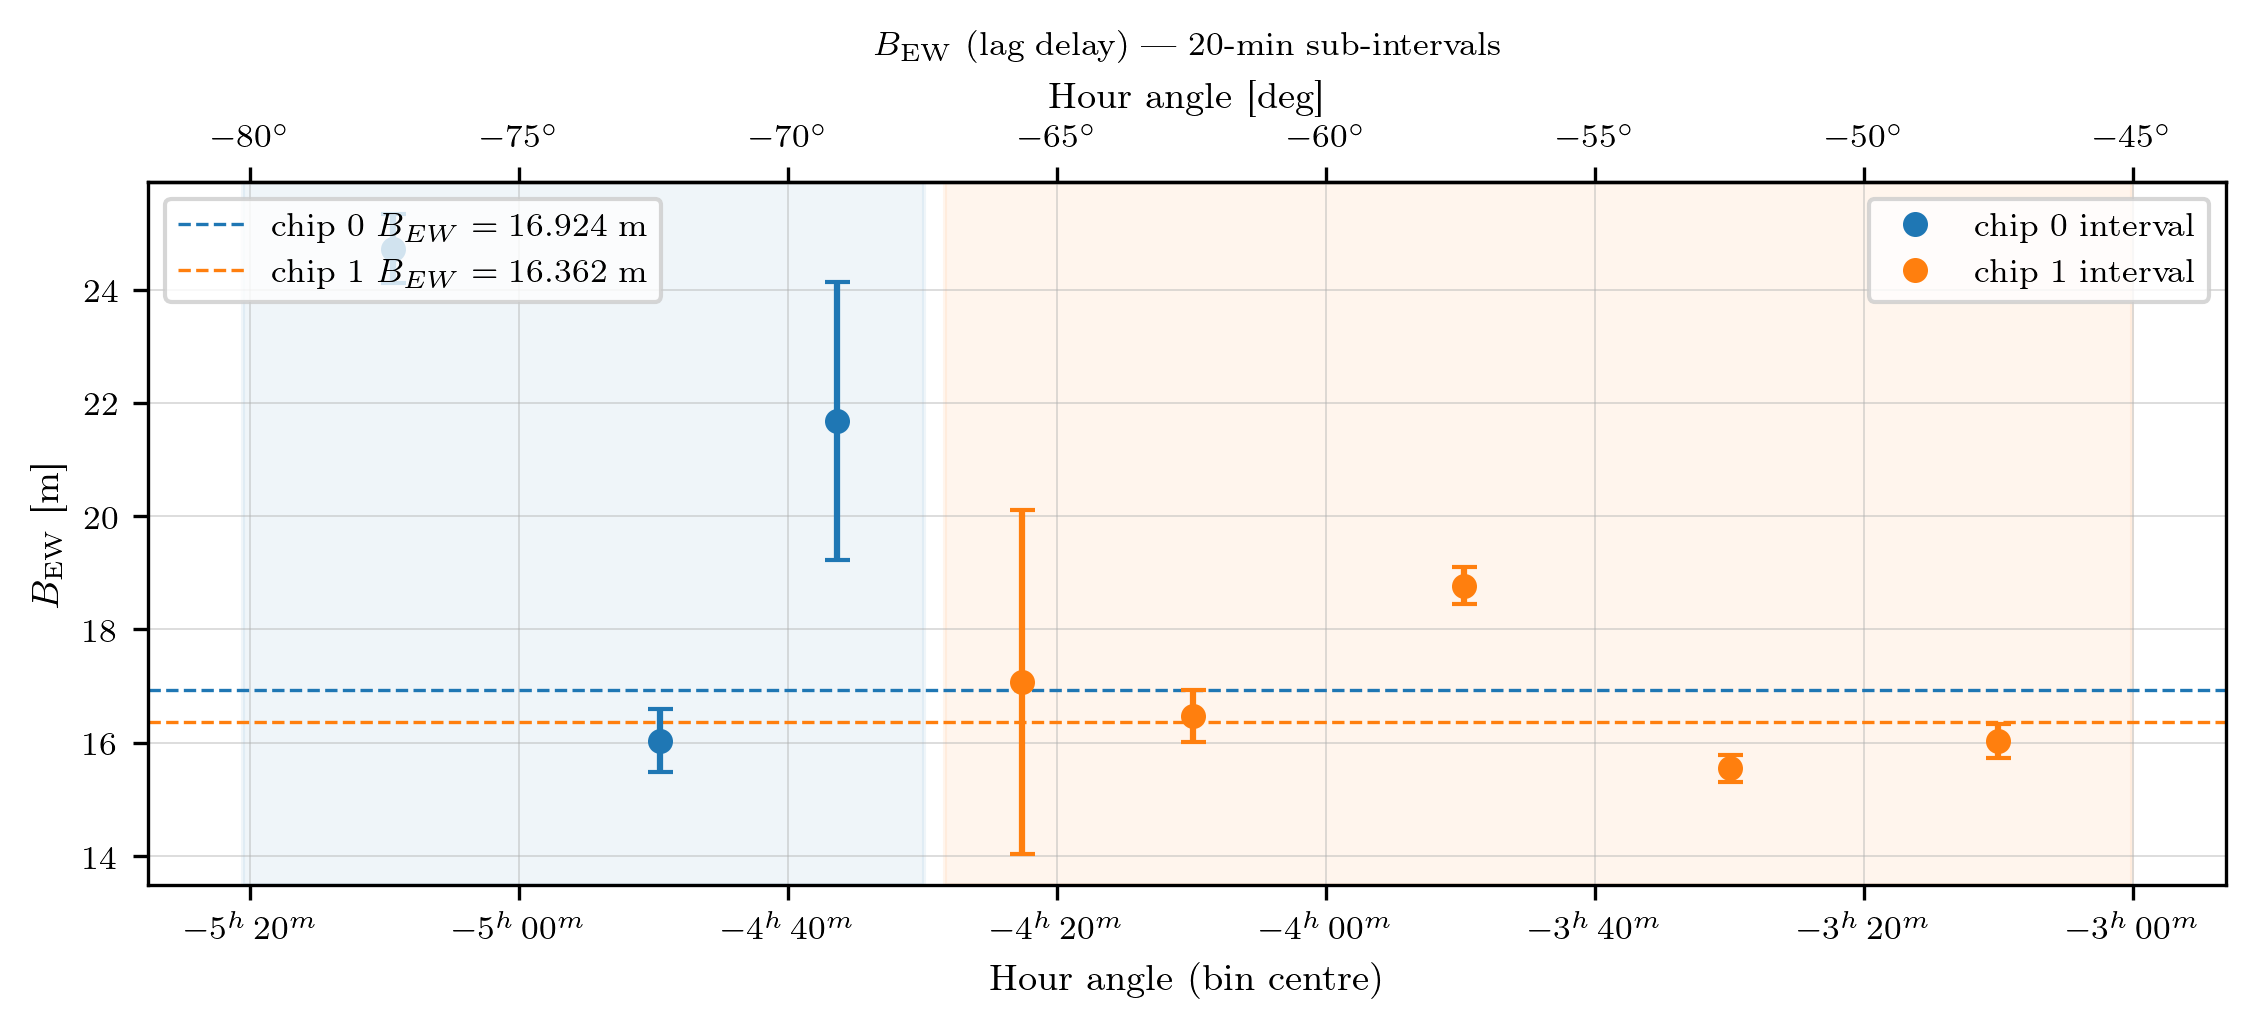

In [8]:
# ---------------------------------------------------------------------------
# B_EW from lag delay — 8 × 20-min HA sub-intervals
# Edges: |HA| = 5h20m, 5h, 4h40m, ..., 2h40m  (step 20 min = 5°)
# Bins that straddle the chip gap are split into one sub-bin per chip.
# ---------------------------------------------------------------------------

_ABS_EDGES  = np.array([80, 75, 70, 65, 60, 55, 50, 45, 40])  # |HA| in degrees
_s          = -1 if ha_deg.mean() < 0 else 1
_HA_EDGES   = np.sort(_s * _ABS_EDGES)                          # signed, ascending
_N_BINS     = len(_HA_EDGES) - 1                                 # 8

# Chip membership for every capture (0 or 1)
_cap_chip = np.zeros(N_cap, dtype=int)
_cap_chip[_split:] = 1

# Build sub-bin list: (lo, hi, boolean mask, chip_idx or None)
_sub_bins = []
for i in range(_N_BINS):
    lo, hi   = _HA_EDGES[i], _HA_EDGES[i + 1]
    mask_bin = (ha_deg >= lo) & (ha_deg < hi)
    chips    = np.unique(_cap_chip[mask_bin])
    if len(chips) > 1:
        for c in chips:
            _sub_bins.append((lo, hi, mask_bin & (_cap_chip == c), int(c)))
    else:
        chip = int(chips[0]) if len(chips) == 1 else None
        _sub_bins.append((lo, hi, mask_bin, chip))

_C_int      = 299792458.0
N_pad_int   = N_CH * 16
_tau_ax_int = np.fft.fftshift(np.fft.fftfreq(N_pad_int, d=DF_HZ)) * 1e9

_res_bins = []   # list of dicts: ha_ctr, B_EW, B_EW_err, chip, n

for lo, hi, mask, chip in _sub_bins:
    n = mask.sum()
    if n < 4:
        continue

    _ha_i   = ha_deg[mask]
    _dc_i   = corr_dc[mask, :]
    _unix_i = unix_sort[mask]

    # Lag delay per capture
    _tau_i = np.full(n, np.nan)
    for k in range(n):
        vis = _dc_i[k, :].copy()
        for _k in BAD_CHANNELS:
            _lo_k = _k - 1 if _k > 0 else _k + 1
            _hi_k = _k + 1 if _k < N_CH - 1 else _k - 1
            vis[_k] = (vis[_lo_k] + vis[_hi_k]) / 2
        lag  = np.fft.fftshift(np.fft.ifft(vis, n=N_pad_int))
        i_pk = np.argmax(np.abs(lag))
        _tau_i[k] = _tau_ax_int[i_pk]

    # sin(h) fit → B_EW
    _dec_i     = np.mean([get_sun(Time(t, format='unix')).dec.deg for t in _unix_i])
    _cos_dec_i = np.cos(np.radians(_dec_i))
    _sin_h_i   = np.sin(np.radians(_ha_i))
    _valid_i   = np.isfinite(_tau_i)
    if _valid_i.sum() < 4:
        continue

    _coeffs_i, (_res_i, *_) = np.polynomial.polynomial.polyfit(
        _sin_h_i[_valid_i], _tau_i[_valid_i], 1, full=True
    )
    B_EW_i = _coeffs_i[1] * 1e-9 * _C_int / _cos_dec_i

    _ni          = _valid_i.sum()
    _resid_std_i = np.sqrt(_res_i[0] / (_ni - 2)) if len(_res_i) else np.nan
    _sin_h_rms_i = np.sqrt(np.sum((_sin_h_i[_valid_i] - _sin_h_i[_valid_i].mean())**2))
    B_EW_err_i   = _resid_std_i * 1e-9 * _C_int / (_cos_dec_i * _sin_h_rms_i)

    chip_lbl = f'chip {chip}' if chip is not None else 'both'
    print(f'HA [{lo:+.1f}° to {hi:+.1f}°]  {chip_lbl:6s}  n={n:3d}  '
          f'B_EW = {B_EW_i:.3f} ± {B_EW_err_i:.3f} m')

    _res_bins.append(dict(ha_ctr=_ha_i.mean(), B_EW=B_EW_i, B_EW_err=B_EW_err_i,
                          chip=chip, lo=lo, hi=hi))

fig, ax = plot_interval_baseline(
    ha_chips=ha_chips,
    baseline_lag_chips=_B_EW_lag_chips,
    interval_results=_res_bins,
)
plt.show()
